## Depth profiles with monthly averages using EasyOneArgoBGCLite data, float 5905103

In [1]:
import numpy as np
from oneargopy.OneArgo import Argo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import gsw
from tqdm import tqdm
import matplotlib.image as mpimg
import earthaccess
import h5netcdf
import seaborn as sns
import xarray as xr
from matplotlib.patches import Rectangle
import dask
import contourpy
from matplotlib import colors

from importlib import reload
import SO_tools as tools; reload(tools)

/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'SO_tools' from '/Users/lilah/Documents/IBIS_Project/SO_tools.py'>

In [2]:
df = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/EasyOneArgoBGCLite_5905103.csv')

In [3]:
#convert to datetime
df['profile_date'] = pd.to_datetime(df['profile_date'],format = 'mixed',utc=True)
df = df.dropna(subset=["profile_date"]) #drop any cycles with no date or lat/lon 

#create season columns
df["year"] = df["profile_date"].dt.year.astype("Int64")
df["month"] = df["profile_date"].dt.month.astype("Int64")

def assign_season(row):
    m = int(row["month"])
    y = int(row["year"])
    if m >= 9:
        return f"{y}-{y+1}"
    elif m <= 4:
        return f"{y-1}-{y}"
    else:
        return f"{y}"

df["season"] = df.apply(assign_season, axis=1)

In [38]:
df

,Unnamed: 0,pressure,temperature,salinity,oxygen,nitrate,pH,chla,chlaFluorescence,bbp700,...,downIrr443_error,downIrr490_error,downIrr555_error,downwellingPar_error,float_id,profile_number,profile_date,year,month,season
0,0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5905103,1,2018-02-16 12:31:57+00:00,2018,2,2017-2018
1,1,320.0,2.107,34.292,212.934,34.606,NaN,0.0011,0.0072,0.000526,...,NaN,NaN,NaN,NaN,5905103,1,2018-02-16 12:31:57+00:00,2018,2,2017-2018
2,2,310.0,2.002,34.269,217.730,34.398,NaN,0.0011,0.0072,0.000514,...,NaN,NaN,NaN,NaN,5905103,1,2018-02-16 12:31:57+00:00,2018,2,2017-2018
3,3,300.0,1.883,34.243,225.218,34.091,NaN,0.0011,0.0072,0.000495,...,NaN,NaN,NaN,NaN,5905103,1,2018-02-16 12:31:57+00:00,2018,2,2017-2018
4,4,290.0,1.795,34.221,232.432,33.899,NaN,0.0011,0.0072,0.000491,...,NaN,NaN,NaN,NaN,5905103,1,2018-02-16 12:31:57+00:00,2018,2,2017-2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12634,12634,115.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5905103,157,2022-05-31 08:50:42+00:00,2022,5,2022
12635,12635,110.0,1.860,33.991,300.559,NaN,NaN,0.0857,0.3698,0.000641,...,NaN,NaN,NaN,NaN,5905103,157,2022-05-31 08:50:42+00:00,2022,5,2022
12636,12636,105.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5905103,157,2022-05-31 08:50:42+00:00,2022,5,2022
12637,12637,90.0,1.730,33.907,316.752,NaN,NaN,0.1301,0.5616,0.000672,...,NaN,NaN,NaN,NaN,5905103,157,2022-05-31 08:50:42+00:00,2022,5,2022


In [4]:
df_2 = df[df['season'].isin(['2019-2020'])]
# df_3 = df_2.groupby('month')['chla'].transform(lambda x: x.mean(axis=1))
df_3 = df_2.groupby(['month', 'pressure'])['temperature'].median()

df_4 = df_3.to_frame()

In [5]:
df_2 = df[df['season'].isin(['2019-2020'])]
df_3 = df_2.groupby(['month', 'pressure'])['chla'].mean()
df_4 = df_3.to_frame()

In [6]:
df_5 = df_4.reset_index()
df_6 = df_5.dropna()

In [9]:
df_6

,month,pressure,chla,month_name
1,1,5.0,0.085900,January
2,1,10.0,0.130767,January
3,1,15.0,0.130767,January
4,1,20.0,0.130767,January
5,1,25.0,0.138633,January
...,...,...,...,...
646,12,1000.0,0.002633,December
647,12,1100.0,0.003167,December
648,12,1200.0,0.003167,December
649,12,1300.0,0.002633,December


In [8]:
import calendar
month_dict = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December",
}

# Apply mapping to the month column
df_6["month_name"] = df_6["month"].map(month_dict)
df_6

,month,pressure,chla,month_name
1,1,5.0,0.085900,January
2,1,10.0,0.130767,January
3,1,15.0,0.130767,January
4,1,20.0,0.130767,January
5,1,25.0,0.138633,January
...,...,...,...,...
646,12,1000.0,0.002633,December
647,12,1100.0,0.003167,December
648,12,1200.0,0.003167,December
649,12,1300.0,0.002633,December


TypeError: 'numpy.int64' object is not iterable

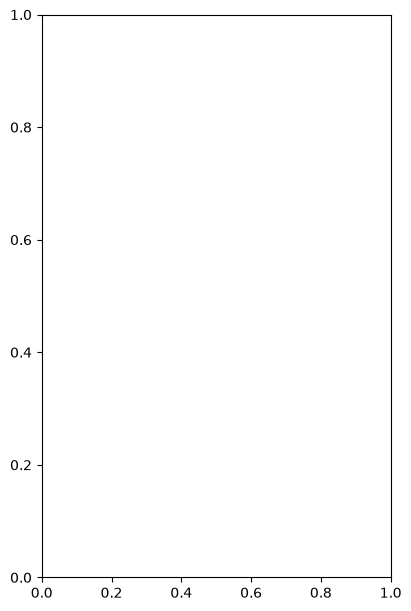

In [32]:
# Create figure and axis
fig = plt.figure(figsize=(4,6), layout='constrained')

# Chlorophyll profile -----------------------------------------------------------------
ax = fig.add_subplot(111)
# date_val = mdates.date2num(group['DATE'].iloc[0])
norm = colors.Normalize(0.5, 12.5)
cmap = plt.get_cmap('tab20b', len(df_6['month'].unique()))
color = cmap(norm(df_6['month']))
# ax.plot(df_plot['temperature'], df_plot['pressure'], lw=2)
for month, g in df_6.groupby("month"): 
    month_label = g["month_name"].iloc[0]

    ax.plot(g["chla"], g["pressure"], color=cmap(norm(month)), label=month_label)

# ax.set_xlim(0, 7)
ax.set_ylim(0, 600)
ax.invert_yaxis()
ax.legend(title="Month", loc="best")
# ax.set_xlabel('Chl-a (mg m$^{-3}$)', fontsize=12)
# ax.set_ylabel('Pressure (dbar)', fontsize=12)
# ax.set_title(f'WMO {str(WMOID)} Chl-a Profiles', fontsize=14)


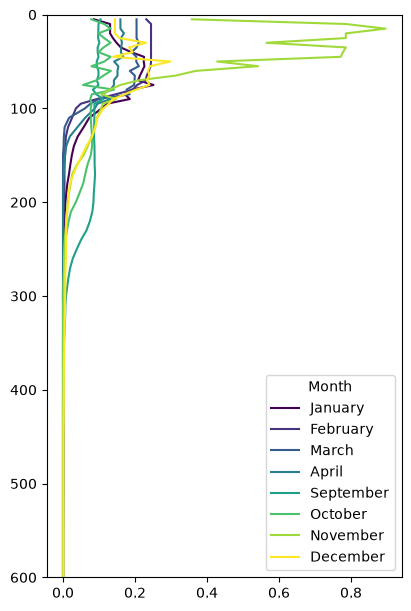

In [37]:
fig = plt.figure(figsize=(4,6), layout='constrained')

ax = fig.add_subplot(111)

unique_months = sorted(df_6['month'].unique()) 
num_months = 8
cmap = plt.get_cmap('viridis', num_months)

# 3. Create a normalization that maps 0 to the first month index, and num_months-1 to the last
norm = colors.Normalize(vmin=0, vmax=num_months - 1)

# 4. In your loop, map the month based on its *position index* in your unique list, not its calendar number
for i, month in enumerate(unique_months):
    g = df_6[df_6['month'] == month]
    month_label = g["month_name"].iloc[0]
    
    # Use the index 'i' instead of the calendar month number
    ax.plot(g["chla"], g["pressure"], color=cmap(norm(i)), label=month_label)

ax.set_ylim(0, 600)
ax.invert_yaxis()
ax.legend(title="Month", loc="best")

## FINAL FIGURE FOR POSTER

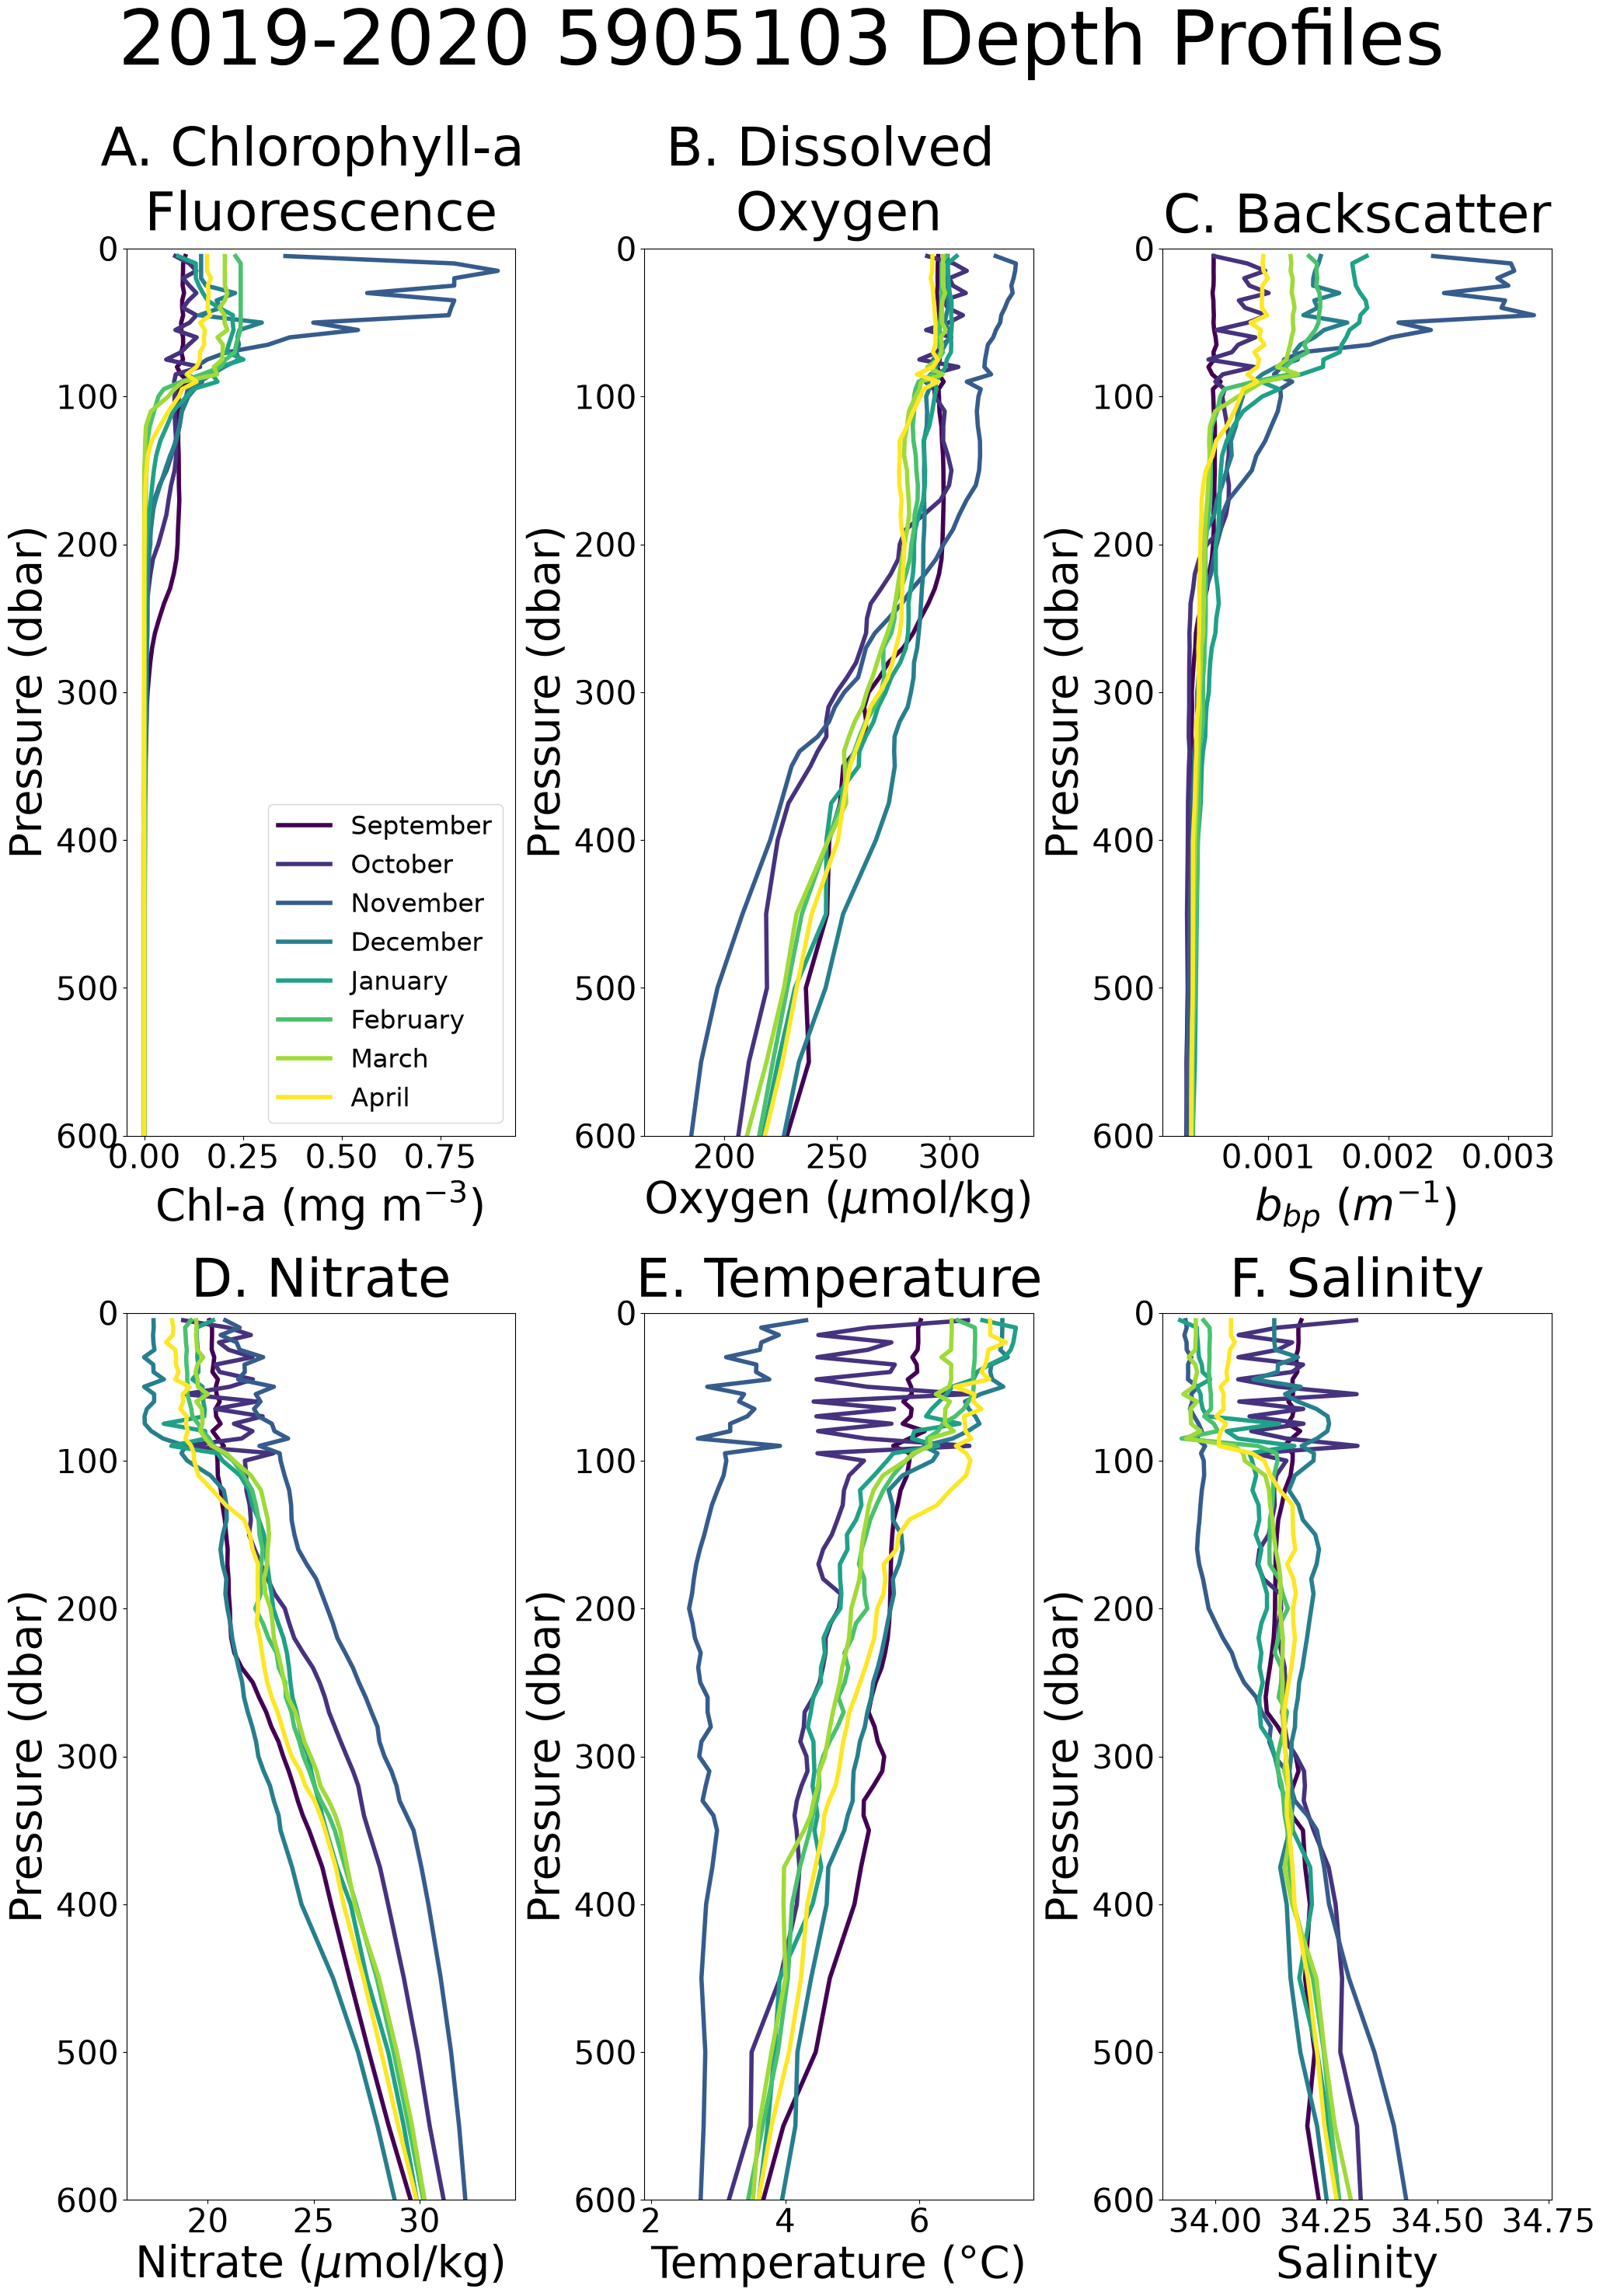

In [49]:

def depth_profiles(df):

    df=df
    #convert to datetime
    df['profile_date'] = pd.to_datetime(df['profile_date'],format = 'mixed',utc=True)
    df = df.dropna(subset=["profile_date"]) #drop any cycles with no date or lat/lon 
    
    #create season columns
    df["year"] = df["profile_date"].dt.year.astype("Int64")
    df["month"] = df["profile_date"].dt.month.astype("Int64")
    
    def assign_season(row):
        m = int(row["month"])
        y = int(row["year"])
        if m >= 9:
            return f"{y}-{y+1}"
        elif m <= 4:
            return f"{y-1}-{y}"
        else:
            return f"{y}"
    
    df["season"] = df.apply(assign_season, axis=1)

    df_2 = df[df['season'].isin(['2019-2020'])]
    
    
    # DEFINE FIGURE ---------------------------------------------------------------
    fig = plt.figure(figsize=(20, 28), layout='constrained')


    
    # CHLA plot -------------------------------------------------------------------
    ax = fig.add_subplot(231)

    df_3 = df_2.groupby(['month', 'pressure'])['chla'].mean()
    df_4 = df_3.to_frame()
    df_5 = df_4.reset_index()
    df_6 = df_5.dropna()

    import calendar
    month_dict = {
        1: "January",
        2: "February",
        3: "March",
        4: "April",
        5: "May",
        6: "June",
        7: "July",
        8: "August",
        9: "September",
        10: "October",
        11: "November",
        12: "December",
    }
    
    df_6["month_name"] = df_6["month"].map(month_dict)
    df = df_6

    raw_months = df_6['month'].unique()
    unique_months = sorted(raw_months, key=lambda m: m - 9 if m >= 9 else m + 3)
    
    num_months = len(unique_months)
    cmap = plt.get_cmap('viridis', num_months)
    norm = colors.Normalize(vmin=0, vmax=num_months - 1)

    for i, month in enumerate(unique_months):
        g = df_6[df_6['month'] == month]
        month_label = g["month_name"].iloc[0]
        ax.plot(g["chla"], g["pressure"], color=cmap(norm(i)), label=month_label, lw=4)

    ax.set_ylim(0, 600)
    ax.invert_yaxis()
    ax.legend(loc="best", fontsize=24)
    ax.set_xlabel('Chl-a (mg m$^{-3}$)', fontsize=40)
    ax.set_ylabel('Pressure (dbar)', fontsize=40)
    ax.tick_params(axis='both', which='major', labelsize=30)
    ax.set_title('A. Chlorophyll-a \nFluorescence', fontsize=50, pad = 15)


    
    # DOXY plot -------------------------------------------------------------------
    ax = fig.add_subplot(232)

    df_3 = df_2.groupby(['month', 'pressure'])['oxygen'].mean()
    df_4 = df_3.to_frame()
    df_5 = df_4.reset_index()
    df_6 = df_5.dropna()

    import calendar
    month_dict = {
        1: "January",
        2: "February",
        3: "March",
        4: "April",
        5: "May",
        6: "June",
        7: "July",
        8: "August",
        9: "September",
        10: "October",
        11: "November",
        12: "December",
    }
    
    df_6["month_name"] = df_6["month"].map(month_dict)
    df = df_6

    raw_months = df_6['month'].unique()
    unique_months = sorted(raw_months, key=lambda m: m - 9 if m >= 9 else m + 3)
    
    num_months = len(unique_months)
    cmap = plt.get_cmap('viridis', num_months)
    norm = colors.Normalize(vmin=0, vmax=num_months - 1)

    for i, month in enumerate(unique_months):
        g = df_6[df_6['month'] == month]
        month_label = g["month_name"].iloc[0]
        ax.plot(g["oxygen"], g["pressure"], color=cmap(norm(i)), label=month_label, lw=4)

    ax.set_ylim(0, 600)
    ax.invert_yaxis()
    # ax.legend(loc="best", fontsize=24)
    ax.set_xlabel(r'Oxygen ($\mu\text{mol/kg}$)', fontsize=40)
    ax.set_ylabel('Pressure (dbar)', fontsize=40)
    ax.tick_params(axis='both', which='major', labelsize=30)
    ax.set_title('B. Dissolved \nOxygen', fontsize=50, pad = 15)

    
    
    
    # BBP700 plot -----------------------------------------------------------------
    ax = fig.add_subplot(233)

    df_3 = df_2.groupby(['month', 'pressure'])['bbp700'].mean()
    df_4 = df_3.to_frame()
    df_5 = df_4.reset_index()
    df_6 = df_5.dropna()

    import calendar
    month_dict = {
        1: "January",
        2: "February",
        3: "March",
        4: "April",
        5: "May",
        6: "June",
        7: "July",
        8: "August",
        9: "September",
        10: "October",
        11: "November",
        12: "December",
    }
    
    df_6["month_name"] = df_6["month"].map(month_dict)
    df = df_6

    raw_months = df_6['month'].unique()
    unique_months = sorted(raw_months, key=lambda m: m - 9 if m >= 9 else m + 3)
    
    num_months = len(unique_months)
    cmap = plt.get_cmap('viridis', num_months)
    norm = colors.Normalize(vmin=0, vmax=num_months - 1)

    for i, month in enumerate(unique_months):
        g = df_6[df_6['month'] == month]
        month_label = g["month_name"].iloc[0]
        ax.plot(g["bbp700"], g["pressure"], color=cmap(norm(i)), label=month_label, lw=4)

    ax.set_ylim(0, 600)
    ax.invert_yaxis()
    # ax.legend(loc="best", fontsize=24)
    ax.set_xlabel(r'$b_{bp}$ ($m^{-1}$)', fontsize=40)
    ax.set_ylabel('Pressure (dbar)', fontsize=40)
    ax.tick_params(axis='both', which='major', labelsize=30)
    ax.set_title('C. Backscatter', fontsize=50, pad = 15)


    

    # NITRATE plot ----------------------------------------------------------------
    ax = fig.add_subplot(234)

    df_3 = df_2.groupby(['month', 'pressure'])['nitrate'].mean()
    df_4 = df_3.to_frame()
    df_5 = df_4.reset_index()
    df_6 = df_5.dropna()

    import calendar
    month_dict = {
        1: "January",
        2: "February",
        3: "March",
        4: "April",
        5: "May",
        6: "June",
        7: "July",
        8: "August",
        9: "September",
        10: "October",
        11: "November",
        12: "December",
    }
    
    
    df_6["month_name"] = df_6["month"].map(month_dict)
    df = df_6

    raw_months = df_6['month'].unique()
    unique_months = sorted(raw_months, key=lambda m: m - 9 if m >= 9 else m + 3)
    
    num_months = len(unique_months)
    cmap = plt.get_cmap('viridis', num_months)
    norm = colors.Normalize(vmin=0, vmax=num_months - 1)

    for i, month in enumerate(unique_months):
        g = df_6[df_6['month'] == month]
        month_label = g["month_name"].iloc[0]
        ax.plot(g["nitrate"], g["pressure"], color=cmap(norm(i)), label=month_label, lw=4)

    ax.set_ylim(0, 600)
    ax.invert_yaxis()
    # ax.legend(loc="best", fontsize=24)
    ax.set_xlabel(r'Nitrate ($\mu\text{mol/kg}$)', fontsize=40)
    ax.set_ylabel('Pressure (dbar)', fontsize=40)
    ax.tick_params(axis='both', which='major', labelsize=30)
    ax.set_title('D. Nitrate', fontsize=50, pad = 15)



    # TEMP PLOT -----------------------------------------------------------------
    ax = fig.add_subplot(235)

    df_3 = df_2.groupby(['month', 'pressure'])['temperature'].mean()
    df_4 = df_3.to_frame()
    df_5 = df_4.reset_index()
    df_6 = df_5.dropna()

    import calendar
    month_dict = {
        1: "January",
        2: "February",
        3: "March",
        4: "April",
        5: "May",
        6: "June",
        7: "July",
        8: "August",
        9: "September",
        10: "October",
        11: "November",
        12: "December",
    }
    
    df_6["month_name"] = df_6["month"].map(month_dict)
    df = df_6

    raw_months = df_6['month'].unique()
    unique_months = sorted(raw_months, key=lambda m: m - 9 if m >= 9 else m + 3)
    
    num_months = len(unique_months)
    cmap = plt.get_cmap('viridis', num_months)
    norm = colors.Normalize(vmin=0, vmax=num_months - 1)
    for i, month in enumerate(unique_months):
        g = df_6[df_6['month'] == month]
        month_label = g["month_name"].iloc[0]
        ax.plot(g["temperature"], g["pressure"], color=cmap(norm(i)), label=month_label, lw=4)

    ax.set_ylim(0, 600)
    ax.invert_yaxis()
    # ax.legend(loc="best", fontsize=24)
    ax.set_xlabel(f'Temperature (\u00B0C)', fontsize=40)
    ax.set_ylabel('Pressure (dbar)', fontsize=40)
    ax.tick_params(axis='both', which='major', labelsize=30)
    ax.set_title('E. Temperature', fontsize=50, pad = 15)


    

    # SALINITY PLOT -----------------------------------------------------------------
    ax = fig.add_subplot(236)

    df_3 = df_2.groupby(['month', 'pressure'])['salinity'].mean()
    df_4 = df_3.to_frame()
    df_5 = df_4.reset_index()
    df_6 = df_5.dropna()

    import calendar
    month_dict = {
        1: "January",
        2: "February",
        3: "March",
        4: "April",
        5: "May",
        6: "June",
        7: "July",
        8: "August",
        9: "September",
        10: "October",
        11: "November",
        12: "December",
    }
    
    df_6["month_name"] = df_6["month"].map(month_dict)
    df = df_6

    raw_months = df_6['month'].unique()
    unique_months = sorted(raw_months, key=lambda m: m - 9 if m >= 9 else m + 3)
    
    num_months = len(unique_months)
    cmap = plt.get_cmap('viridis', num_months)
    norm = colors.Normalize(vmin=0, vmax=num_months - 1)
    for i, month in enumerate(unique_months):
        g = df_6[df_6['month'] == month]
        month_label = g["month_name"].iloc[0]
        ax.plot(g["salinity"], g["pressure"], color=cmap(norm(i)), label=month_label, lw=4)

    ax.set_ylim(0, 600)
    ax.invert_yaxis()
    # ax.legend(loc="best", fontsize=24)
    ax.set_xlabel('Salinity', fontsize=40)
    ax.set_ylabel('Pressure (dbar)', fontsize=40)
    ax.tick_params(axis='both', which='major', labelsize=30)
    ax.set_title('F. Salinity', fontsize=50, pad = 15)

    
    fig.suptitle('2019-2020 5905103 Depth Profiles', fontsize = 70, y=1.05)
    
    plt.show()

    fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures_Summer/final_fig_depth_5905103', transparent=True, bbox_inches='tight')



depth_profiles(df = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/EasyOneArgoBGCLite_5905103.csv'))
